In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/simbarashemutyambizi/bike-dataset/Bike.csv
/kaggle/input/datasets/simbarashemutyambizi/final-fuel-dataset/Final_Bike_Dataset.csv
/kaggle/input/datasets/simbarashemutyambizi/final-fuel-dataset/Final_fuel_Dataset.csv


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.decomposition import PCA

#models
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor

In [3]:
fuel_df=pd.read_csv("/kaggle/input/datasets/simbarashemutyambizi/final-fuel-dataset/Final_fuel_Dataset.csv")
bike_df=pd.read_csv("/kaggle/input/datasets/simbarashemutyambizi/final-fuel-dataset/Final_Bike_Dataset.csv")

In [4]:
fuel_df.head()

,Unnamed: 0,FullDate,Brand Name,Region Name,Suburb,Postcode,Lat,Long,Diesel,Premium 98,Premium 95,Unleaded 91,Premium Diesel,LPG,Low Aromatic Fuel,Ethanol 105 (E85),Ethanol 94 (E10),Region Name_encoded,Suburb_encoded,Brand Name_encoded
0,0,2018/04/01,Independent,Darwin,Darwin,800.0,-12.453169,130.838155,125.9,0.0,0.0,125.9,0.0,0.0,0.0,0.0,0.0,0,0,0
1,1,2018/04/01,Coles Express,Darwin,Darwin,800.0,-12.454479,130.838773,149.9,0.0,166.9,149.9,0.0,0.0,0.0,0.0,0.0,0,0,1
2,2,2018/04/01,United,Darwin,Darwin,800.0,-12.458111,130.836149,147.7,0.0,157.7,146.7,0.0,0.0,0.0,0.0,145.7,0,0,2
3,3,2018/04/01,Puma Energy,Darwin,Darwin,800.0,-12.459371,130.837418,147.9,176.9,157.9,146.9,0.0,0.0,0.0,0.0,0.0,0,0,3
4,5,2018/04/01,Coles Express,Darwin,Casuarina,810.0,-12.376822,130.882005,149.9,0.0,166.9,149.9,0.0,0.0,0.0,0.0,0.0,0,1,1


In [5]:
#possible cleaning
def minor_cleaning(fuel_df):
    #change full date to date time object
    #dropping Suburb_encoded, Region Name_encoded and Brand Name_encoded to later perform dummy encoding
    #Converting all suburb variables to title, removing duplicate values registered as unique based on Capitalization, for example Darwin and DARWIN
    #droppinf unnamed: 0
    fuel_df["FullDate"]=pd.to_datetime(fuel_df["FullDate"])
    fuel_df["Postcode"]=fuel_df["Postcode"].astype(object)
    fuel_df.drop(["Suburb_encoded","Region Name_encoded","Brand Name_encoded"],axis="columns",inplace=True)
    fuel_df["Suburb"]=fuel_df["Suburb"].str.title()
    fuel_df.drop('Unnamed: 0',axis="columns",inplace=True)

    return fuel_df

fuel_df=minor_cleaning(fuel_df)    
        

## Univariant analysis

In [6]:
#starting with numerical data
fuel_df.dtypes

FullDate             datetime64[ns]
Brand Name                   object
Region Name                  object
Suburb                       object
Postcode                     object
Lat                         float64
Long                        float64
Diesel                      float64
Premium 98                  float64
Premium 95                  float64
Unleaded 91                 float64
Premium Diesel              float64
LPG                         float64
Low Aromatic Fuel           float64
Ethanol 105 (E85)           float64
Ethanol 94 (E10)            float64
dtype: object

In [7]:
fuel_df.columns

Index(['FullDate', 'Brand Name', 'Region Name', 'Suburb', 'Postcode', 'Lat',
       'Long', 'Diesel', 'Premium 98', 'Premium 95', 'Unleaded 91',
       'Premium Diesel', 'LPG', 'Low Aromatic Fuel', 'Ethanol 105 (E85)',
       'Ethanol 94 (E10)'],
      dtype='object')

In [8]:
#splitting the datasets into diesel,premium 98 and premium 95 and unleaded 91 datasets for better analysis of non zero values
diesel=fuel_df[['FullDate', 'Brand Name', 'Region Name', 'Suburb', 'Postcode', 'Lat',
       'Long', 'Diesel']]
premium_98=fuel_df[['FullDate', 'Brand Name', 'Region Name', 'Suburb', 'Postcode', 'Lat',
       'Long', 'Premium 98']]
premium_95=fuel_df[['FullDate', 'Brand Name', 'Region Name', 'Suburb', 'Postcode', 'Lat',
       'Long', 'Premium 95']]
unleaded_91=fuel_df[['FullDate', 'Brand Name', 'Region Name', 'Suburb', 'Postcode', 'Lat',
       'Long', 'Unleaded 91']]

In [9]:
diesel=diesel.loc[diesel["Diesel"]>0]
premium_98=premium_98.loc[premium_98["Premium 98"]>0]
premium_95=premium_95.loc[premium_95["Premium 95"]>0]
unleaded_91=unleaded_91.loc[unleaded_91["Unleaded 91"]>0]

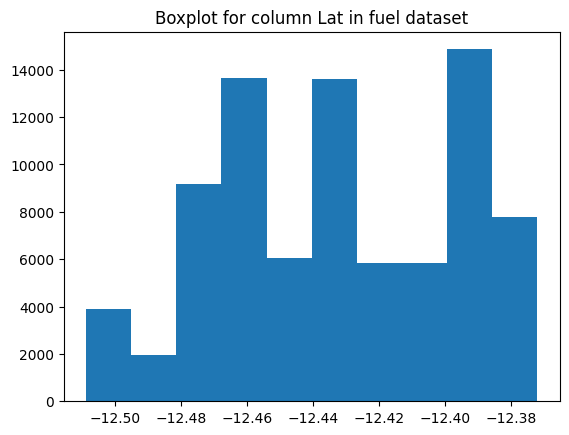

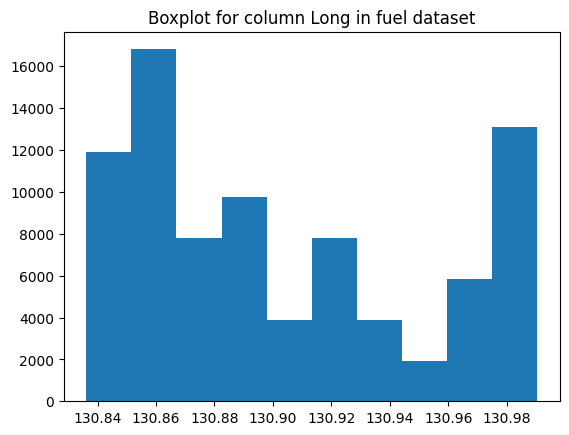

In [10]:
for n in ['Lat', 'Long']:
    plt.hist(fuel_df[n])
    plt.title(f"Boxplot for column {n} in fuel dataset")
    plt.show()

In [11]:
#diesel analysis
def univariate_analysis(df,target,cat1,cat2):
    plt.hist(df[target])
    plt.title(f"Distribution of {target} fuel dataframe")
    plt.show()
    
    print(df.describe())
    print ("---------------------------------------------------------")
    print("Brand name count")
    print(df[cat1].value_counts().to_frame())

    print("---------------------------------------------------------------")
    print("Pie chart of suburb distribution")
    suburb_counts = df['Suburb'].value_counts()

    # 2. Create the plot
    plt.figure(figsize=(10, 8))
    plt.pie(
        suburb_counts, 
        labels=suburb_counts.index, 
        autopct='%1.1f%%',  
        colors=plt.cm.Paired.colors # Uses a pre-set color palette
    )
    
    # 3. Add a title and show
    plt.title('Distribution of records by Suburb')
    plt.axis('equal')  # Ensures the pie is drawn as a circle
    plt.show()

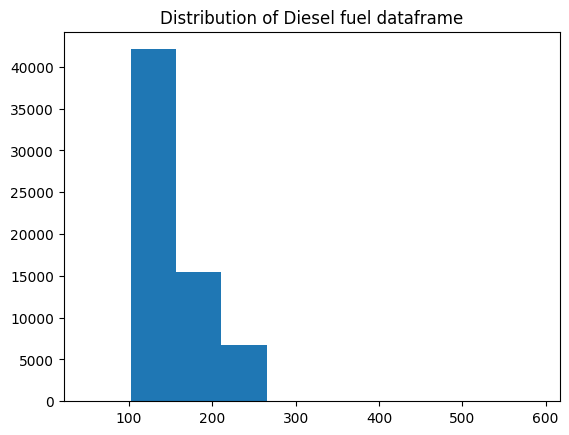

                            FullDate           Lat          Long        Diesel
count                          64268  64268.000000  64268.000000  64268.000000
mean   2021-01-01 17:28:21.748926464    -12.433583    130.900294    159.029355
min              2018-01-01 00:00:00    -12.508780    130.836149     48.658064
25%              2019-05-23 00:00:00    -12.459371    130.855703    134.900000
50%              2020-11-23 00:00:00    -12.433454    130.883836    149.700000
75%              2022-07-14 00:00:00    -12.396662    130.947550    182.500000
max              2024-11-01 00:00:00    -12.373514    130.990370    589.700000
std                              NaN      0.034939      0.052265     34.885577
---------------------------------------------------------
Brand name count
                     count
Brand Name                
Puma Energy          19413
United               13636
Coles Express        10366
BP                   10148
FuelXpress            3344
On The Run            181

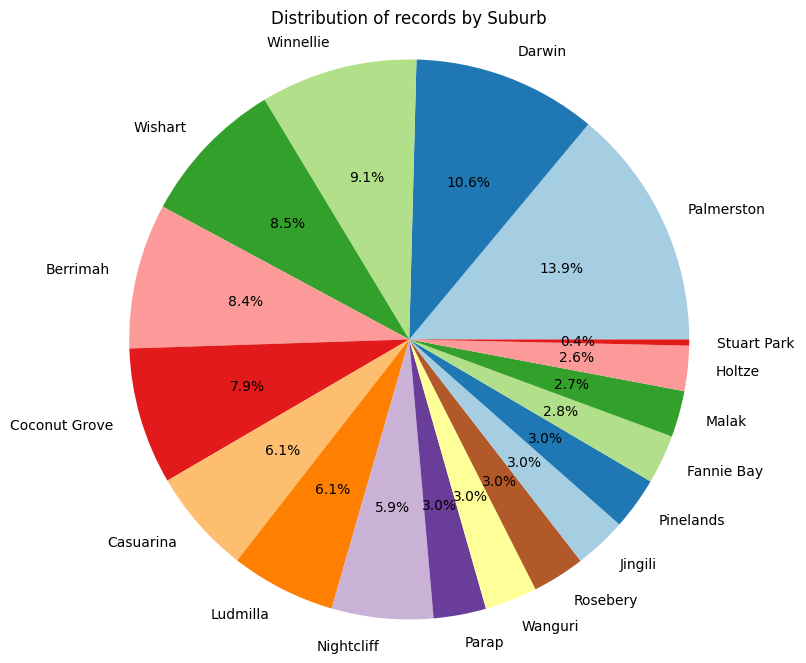

In [12]:
univariate_analysis(diesel,"Diesel","Brand Name", "Region Name")

The Diesel column represent a rightly skewed distribution, with a mean of AUD 159.00 and a standard deviation of AUD 34.88. Which means that on average, each record of Diesel is AUD 34.88 away from the mean (in both positive and negative directions).

The majority of the data is between AUD 134 to AUD 182, with the medium value being closer to the 25th percentile, potential informing us that mmost of the data consists of values below AUD 150.00  

Under the Brand Name column in this dataframe, we see that the top five popular brands are Puma, United, Coles Express, BP and Fuel express, with Shell brands being the least recorded values

Palmerston is the most recorded Suburb to purchase Diesel type fuel, making 13.3% of the dataset, followed by Darwin with 10.6 and Winnelie with 9.1. We will also come to realise that the most frequent suburbs counts change per fuel types as well, showing variation in demand of fuel types per neighbourhood.


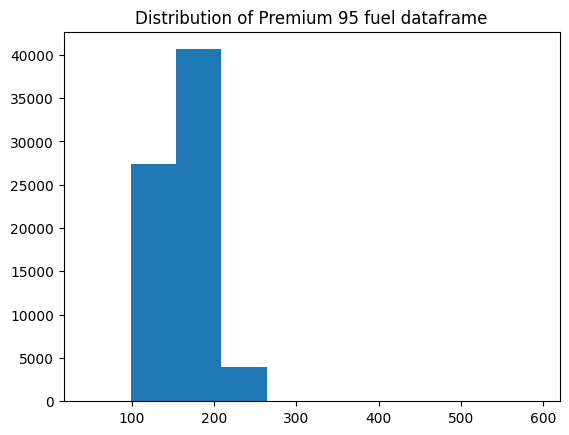

                            FullDate           Lat          Long    Premium 95
count                          71973  71973.000000  71973.000000  71973.000000
mean   2021-02-06 01:50:52.894835456    -12.430178    130.901353    165.683522
min              2018-01-01 00:00:00    -12.508780    130.836149     44.580555
25%              2019-07-11 00:00:00    -12.459371    130.855712    147.700000
50%              2020-12-22 00:00:00    -12.427976    130.883700    162.233333
75%              2022-08-20 00:00:00    -12.394908    130.963210    189.700000
max              2024-11-01 00:00:00    -12.372055    130.990370    592.700000
std                              NaN      0.037847      0.053419     26.474696
---------------------------------------------------------
Brand name count
                     count
Brand Name                
Puma Energy          17502
United               13634
Coles Express        10366
BP                    8200
Caltex Woolworths     7640
Caltex                418

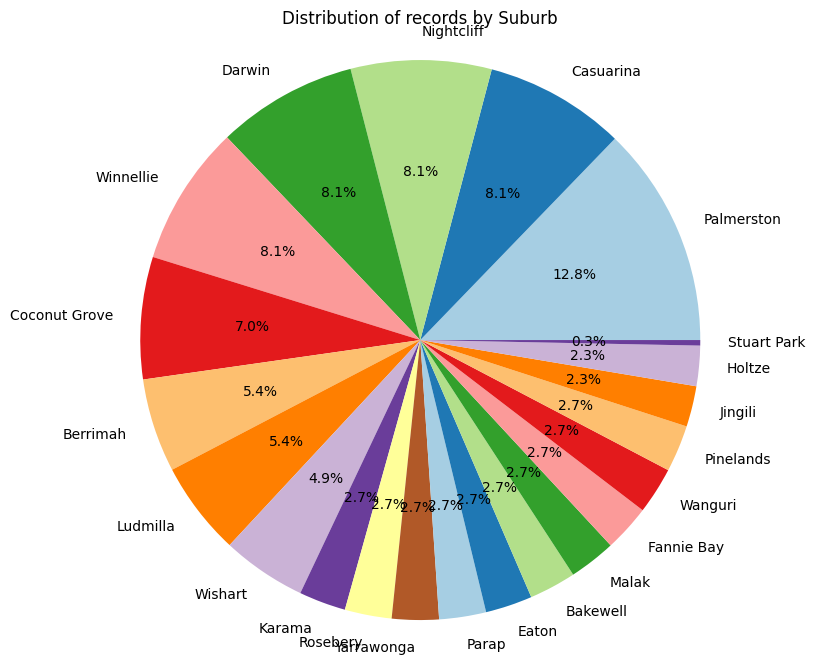

In [13]:
univariate_analysis(premium_95,"Premium 95","Brand Name", "Region Name")

Under the Premium 95 column, we see that the distribution of the data is rightly skewed just like the Diesel data, with a mean value of AUD 165.00 and a standard deviation of AUD 26. 

The minimum price is AUD 44 and the max price we see is AUD 592.00, showing extreme outliers in the dataset, which may impact the performance of the model in the future.
The normal distribution of the data lies between AUD 147 and AUD 189.

Puma, United, Coles and BP are still amongst the top 4 brands seen thus far. Stuart and Holze remain the least popular suburbs in this dataset and Palmerston, Casuarina and Nightcliff are the top three.

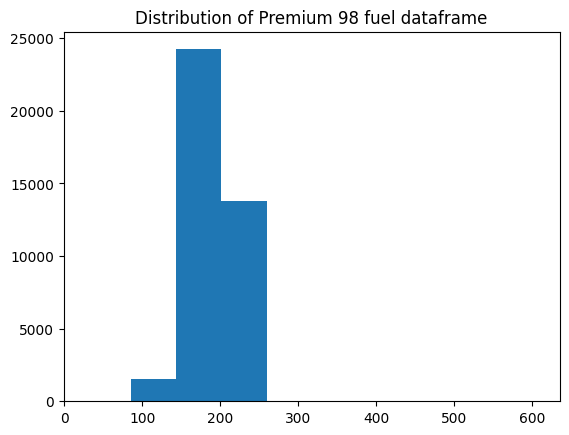

                            FullDate           Lat          Long    Premium 98
count                          39613  39613.000000  39613.000000  39613.000000
mean   2021-04-05 14:14:02.814227712    -12.432240    130.904216    192.021820
min              2018-01-01 00:00:00    -12.508780    130.836149     28.231081
25%              2019-11-19 00:00:00    -12.459371    130.855965    174.700000
50%              2021-03-16 00:00:00    -12.432900    130.893602    184.700000
75%              2022-09-16 00:00:00    -12.397213    130.926545    218.500000
max              2024-11-01 00:00:00    -12.373514    130.990370    606.200000
std                              NaN      0.033431      0.051527     28.465078
---------------------------------------------------------
Brand name count
             count
Brand Name        
Puma Energy  19280
United        4837
Caltex        4185
BP            3588
On The Run    2920
FuelXpress    2917
AMPOL         1659
Liberty        227
------------------------

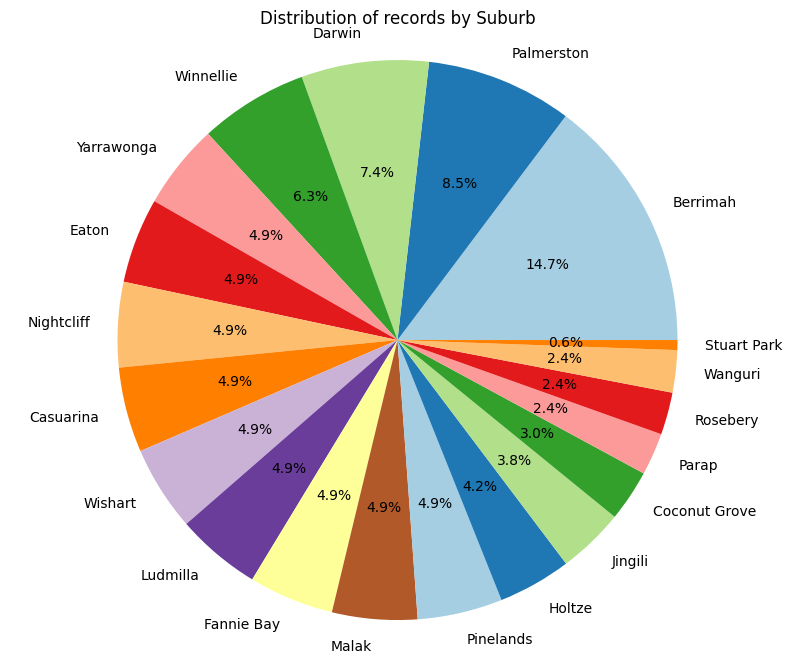

In [14]:
univariate_analysis(premium_98,"Premium 98","Brand Name", "Region Name")

The main thing to notice here is that Berrimah is the most popular neighbourhood in thsi dataset, overtaking Palmerston with a difference of 7%. In addition to that we realise that this dataframe has lesser brands compare to the previous two, showing variation in brand names per fuel type.

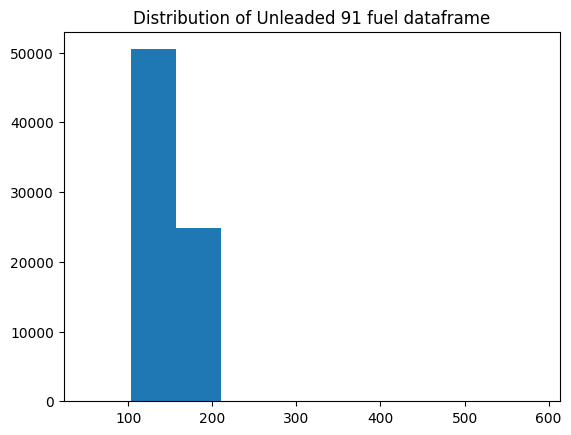

                            FullDate           Lat          Long   Unleaded 91
count                          75404  75404.000000  75404.000000  75404.000000
mean   2021-01-25 04:42:22.209962240    -12.430514    130.900854    152.125284
min              2018-01-01 00:00:00    -12.508780    130.836149     49.950000
25%              2019-05-30 00:00:00    -12.459371    130.855703    134.100000
50%              2020-12-08 00:00:00    -12.427976    130.883836    149.500000
75%              2022-08-10 00:00:00    -12.396662    130.941972    175.500000
max              2024-11-01 00:00:00    -12.372055    130.990370    586.200000
std                              NaN      0.037153      0.052958     25.852455
---------------------------------------------------------
Brand name count
                     count
Brand Name                
Puma Energy          19413
United               13636
Coles Express        10366
BP                    8201
Caltex Woolworths     7640
Caltex                418

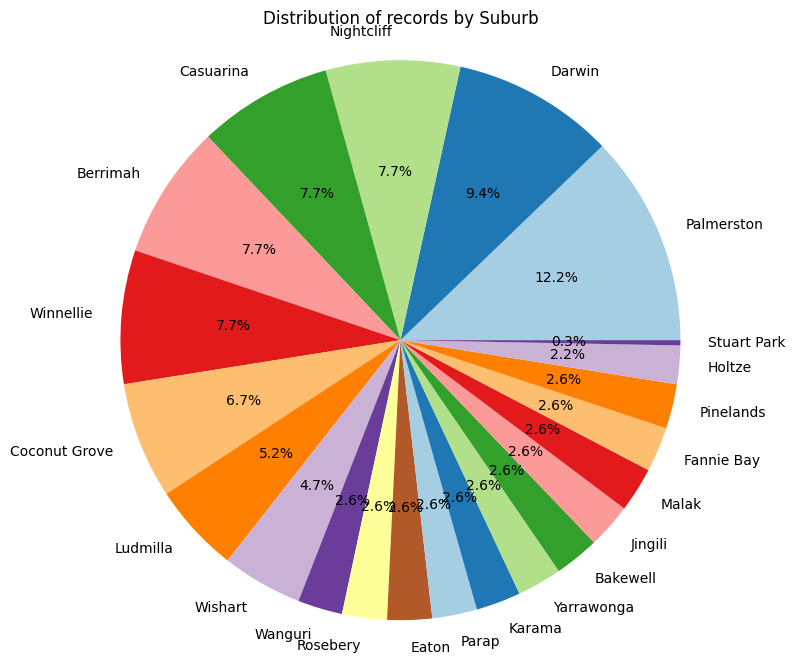

In [15]:
univariate_analysis(unleaded_91,"Unleaded 91","Brand Name", "Region Name")

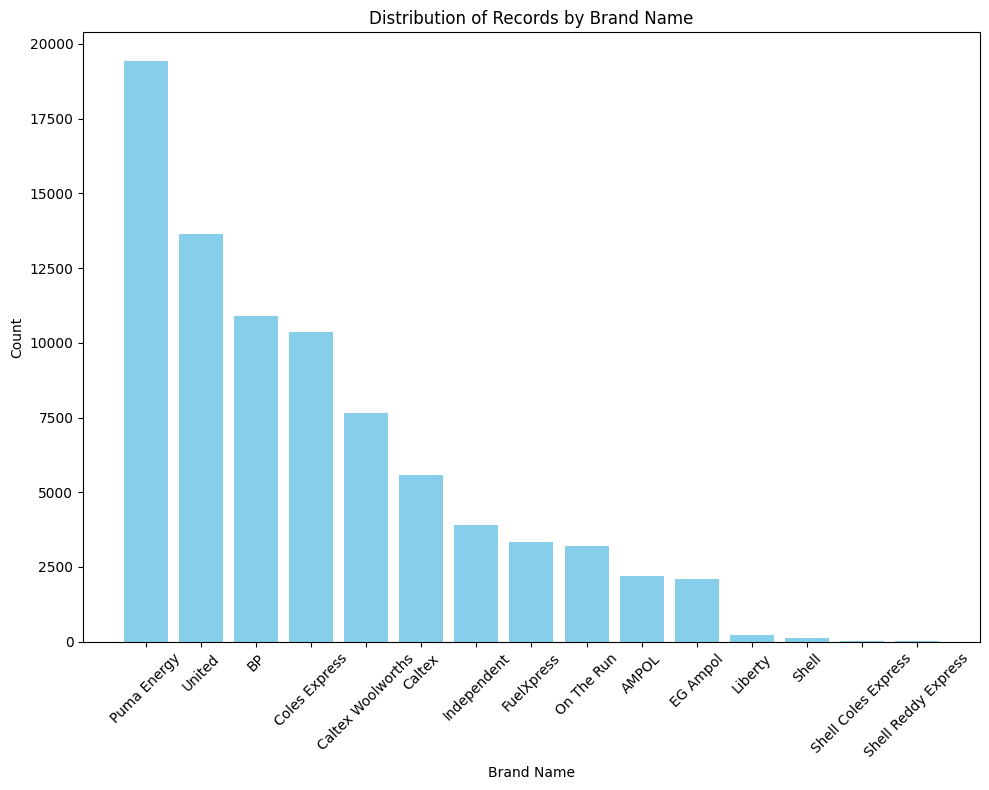

In [16]:
#overal analysis of the entir dataset
#BRAND POPULARITY

brand_count = fuel_df["Brand Name"].value_counts()

plt.figure(figsize=(10, 8))
plt.bar(
    x=brand_count.index, 
    height=brand_count.values,
    color='skyblue'
)

plt.title('Distribution of Records by Brand Name')
plt.xlabel('Brand Name')
plt.ylabel('Count')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [17]:
fuel_df["Region Name"].value_counts()

Region Name
Darwin        63772
Palmerston    18931
Name: count, dtype: int64

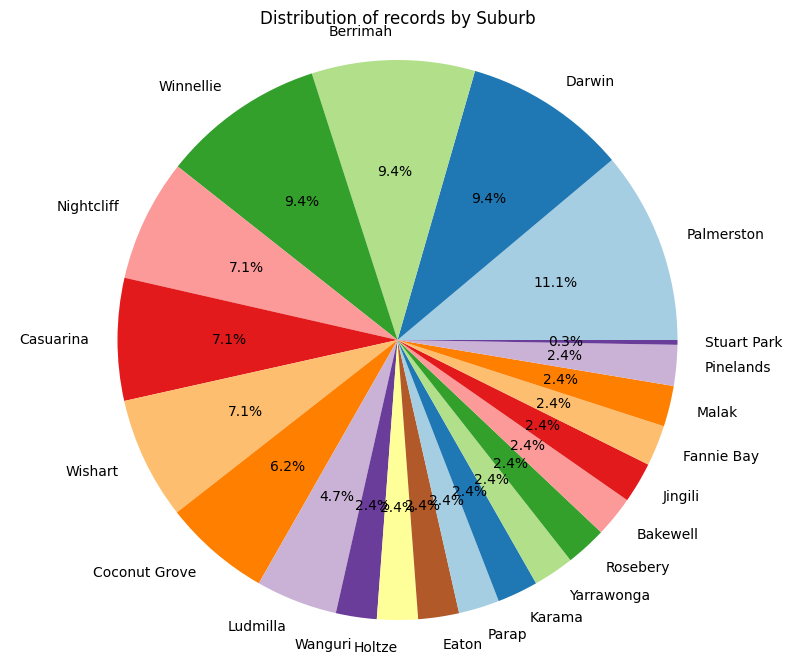

In [18]:
suburb_counts = fuel_df['Suburb'].value_counts()


plt.figure(figsize=(10, 8))
plt.pie(
    suburb_counts, 
    labels=suburb_counts.index, 
    autopct='%1.1f%%',  
    colors=plt.cm.Paired.colors 
)


plt.title('Distribution of records by Suburb')
plt.axis('equal') 
plt.show()

## Bivariant analysis

In [19]:
#numerical to numerical
fuel_df.select_dtypes([int,float]).corr()

,Lat,Long,Diesel,Premium 98,Premium 95,Unleaded 91,Premium Diesel,LPG,Low Aromatic Fuel,Ethanol 105 (E85),Ethanol 94 (E10)
Lat,1.000000,-0.645469,-0.069967,-0.008783,0.122192,0.124987,-0.084014,0.018456,-0.024411,-0.233725,-0.031284
Long,-0.645469,1.000000,-0.052767,0.040789,-0.036943,-0.063435,0.278884,0.063814,0.012444,0.070830,-0.085103
Diesel,-0.069967,-0.052767,1.000000,0.137637,0.225876,0.283373,-0.543376,-0.344675,0.194398,0.122303,0.069205
Premium 98,-0.008783,0.040789,0.137637,1.000000,0.254281,0.350182,-0.042141,-0.010584,-0.289677,0.064601,-0.252665
Premium 95,0.122192,-0.036943,0.225876,0.254281,1.000000,0.856620,0.122766,-0.303694,0.161049,0.082791,0.026691
Unleaded 91,0.124987,-0.063435,0.283373,0.350182,0.856620,1.000000,0.099989,-0.162631,0.126529,0.072834,0.001689
Premium Diesel,-0.084014,0.278884,-0.543376,-0.042141,0.122766,0.099989,1.000000,0.121497,-0.182276,-0.128539,-0.159019
LPG,0.018456,0.063814,-0.344675,-0.010584,-0.303694,-0.162631,0.121497,1.000000,-0.100789,-0.071075,0.028684
Low Aromatic Fuel,-0.024411,0.012444,0.194398,-0.289677,0.161049,0.126529,-0.182276,-0.100789,1.000000,-0.067083,-0.082990
Ethanol 105 (E85),-0.233725,0.070830,0.122303,0.064601,0.082791,0.072834,-0.128539,-0.071075,-0.067083,1.000000,0.302448


The overal analsis of the entire dataset presents nothing significant, and considering that besides the different fuel types, we we only have Lat and Long columns.

## Do the top five brands charge on average higher prices compared to the rest.

To avoid doing this multiple times, we will sum Diesel, Premium 95,98 and Unleaded 91 into "Total Price" column and perform the analysis

In [20]:
fuel_df["Total_price"]= fuel_df["Diesel"] + fuel_df["Premium 95"] + fuel_df["Premium 98"] + fuel_df["Unleaded 91"]
##create a sample dataset with only data from the top five brands and a population
top_brands = ['Coles Express', 'United', 'Puma Energy', 'Caltex Woolworths', 'BP']

# Use .isin() to filter for these brands
top_five_df = fuel_df.loc[fuel_df["Brand Name"].isin(top_brands)]

# Use the tilde (~) operator to select everything NOT in that list
non_top_five_df = fuel_df.loc[~fuel_df["Brand Name"].isin(top_brands)]

In [21]:
top_five_df["Brand Name"].unique()

array(['Coles Express', 'United', 'Puma Energy', 'Caltex Woolworths',
       'BP'], dtype=object)

In [22]:
from statsmodels.stats.weightstats import ztest as ztest

# one sample Z-test with the top five and non top five data
sample_mean =top_five_df["Total_price"].mean()
pop_mean =non_top_five_df["Total_price"].mean()
pop_std =non_top_five_df["Total_price"].std() 
n = len(top_five_df)
alpha=0.05
_,p_value=ztest(top_five_df["Total_price"], value = pop_mean, alternative = "larger")
if p_value >= alpha:
    print("Conclusion: Accept the H0 hypothesis, top five fuel prices is not greater than population prices)")
else:
    print("Conclusion: Accept the H1 Hypothesis, top five fuel prices are greater than the population prices")
    

Conclusion: Accept the H1 Hypothesis, top five fuel prices are greater than the population prices


## Conclusion: The top five data has higher fuel prices than of the population.

## Does the number of brands per fuel type lead to variation in fuel prices

In [23]:
# Group by Suburb, calculate the mean of Total_price, and sort in descending order
suburb_to_price=fuel_df.groupby(["Suburb"])["Total_price"].mean().reset_index().sort_values(by="Total_price", ascending=False)
suburb_to_price

,Suburb,Total_price
17,Stuart Park,750.892952
15,Pinelands,666.245446
6,Fannie Bay,657.561760
11,Malak,648.429063
8,Jingili,600.193271
16,Rosebery,579.628899
18,Wanguri,578.135161
14,Parap,576.701244
7,Holtze,574.430459
10,Ludmilla,571.901936


Despite palmerston and Casuarina having a large amount of records in the dataset, Stuart park, Pinelands  and Fannie bay have higher average fuel prices compared to these suburbs. What could be the reason for this.

In [24]:
suburb_to_count=fuel_df.groupby(["Suburb"])["Brand Name"].nunique().reset_index()
suburb_valu=pd.merge(suburb_to_count,suburb_to_price, on="Suburb")
suburb_valu

,Suburb,Brand Name,Total_price
0,Bakewell,2,317.722362
1,Berrimah,5,450.780508
2,Casuarina,6,490.370296
3,Coconut Grove,2,521.359664
4,Darwin,6,465.339479
5,Eaton,2,512.000326
6,Fannie Bay,2,657.561760
7,Holtze,1,574.430459
8,Jingili,2,600.193271
9,Karama,2,318.289426


In [25]:
suburb_value=pd.DataFrame(suburb_valu)
suburb_value.select_dtypes(["int","float"]).corr()

,Brand Name,Total_price
Brand Name,1.000000,-0.421828
Total_price,-0.421828,1.000000


## After performing correlation analysis on the number of  unique Brand counts to Total fuel price, we have identified a negative correlation, as the Number of unique brands increases, the average fuel price decreases as well by 42%. Which will be a significant variable to include in model under get dummy variables.

In [26]:

fuel_df["Year"]=fuel_df["FullDate"].dt.year

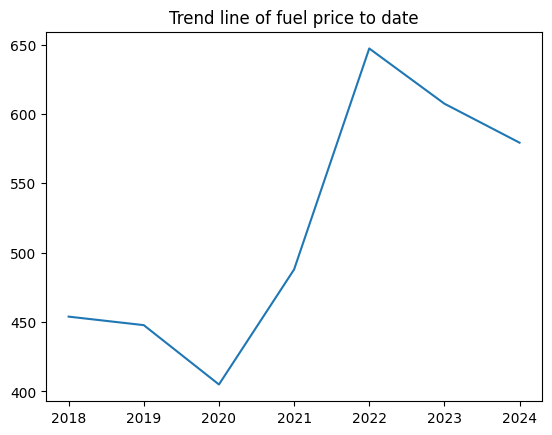

In [27]:
yearly_trends=fuel_df.groupby(["Year"])["Total_price"].mean().reset_index()
plt.plot(yearly_trends["Year"],yearly_trends["Total_price"])
plt.title("Trend line of fuel price to date")
plt.show()

Post 2020, we see a sharp increase in fuel price peaking in 2022, could bike numbers have the same trend 

## Is there variation in average fuel prices based on Brand names?

In [28]:
total_price_to_brand=fuel_df.groupby(["Brand Name"])["Total_price"].mean().reset_index().sort_values(by="Total_price", ascending=False)
total_price_to_brand["Total_price"].describe()

count     15.000000
mean     499.508306
std      159.680744
min       79.116964
25%      444.727535
50%      514.925680
75%      581.879674
max      750.892952
Name: Total_price, dtype: float64

In [29]:
df=pd.read_csv("/kaggle/input/datasets/simbarashemutyambizi/bike-dataset/Bike.csv")
df.columns

Index(['Leg1-2', 'Leg1-3', 'Leg1-4', 'Leg1-5', 'Leg2-1', 'Leg2-3', 'Leg2-4',
       'Leg2-5', 'Leg3-1', 'Leg3-2', 'Leg3-4', 'Leg3-5', 'Leg4-1', 'Leg4-2',
       'Leg4-3', 'Leg4-5', 'Leg5-1', 'Leg5-2', 'Leg5-3', 'Leg5-4', 'Legs',
       'comparison', 'latitude', 'leg1_enter', 'leg1_exit', 'leg1_total',
       'leg2_enter', 'leg2_exit', 'leg2_total', 'leg3_enter', 'leg3_exit',
       'leg3_total', 'leg4_enter', 'leg4_exit', 'leg4_total', 'leg5_enter',
       'leg5_exit', 'leg5_total', 'longitude', 'not known', 'site_id', 'year',
       'Trips/hour'],
      dtype='object')

In [30]:
bike_df=bike_df[['Count_Date','Leg1-2', 'Leg1-3', 'Leg1-4', 'Leg1-5', 'Leg2-1', 'Leg2-3', 'Leg2-4',
       'Leg2-5', 'Leg3-1', 'Leg3-2', 'Leg3-4', 'Leg3-5', 'Leg4-1', 'Leg4-2',
       'Leg4-3', 'Leg4-5', 'Leg5-1', 'Leg5-2', 'Leg5-3', 'Leg5-4', 'Legs',
       'comparison', 'latitude', 'leg1_enter', 'leg1_exit', 'leg1_total',
       'leg2_enter', 'leg2_exit', 'leg2_total', 'leg3_enter', 'leg3_exit',
       'leg3_total', 'leg4_enter', 'leg4_exit', 'leg4_total', 'leg5_enter',
       'leg5_exit', 'leg5_total', 'longitude', 'not known', 'site_id', 'year',
       'Trips/hour']]

In [31]:
bike_df.rename({"Count_Date":"FullDate"},inplace=True,axis="columns")

In [32]:
bike_df["FullDate"] = pd.to_datetime(bike_df["FullDate"], dayfirst=True)


## Jumping straight to model for bike

In [35]:
bike_df["site_id"]=bike_df["site_id"].astype(object)
bike_df["year"]=bike_df["year"].astype(object)

In [36]:
bike_df["site_id"].nunique()

77

In [37]:
bike_df=bike_df[['Leg1-2', 'Leg1-3', 'Leg1-4', 'Leg1-5', 'Leg2-1', 'Leg2-3',
       'Leg2-4', 'Leg2-5', 'Leg3-1', 'Leg3-2', 'Leg3-4', 'Leg3-5', 'Leg4-1',
       'Leg4-2', 'Leg4-3', 'Leg4-5', 'Leg5-1', 'Leg5-2', 'Leg5-3', 'Leg5-4',
       'Legs', 'comparison', 'latitude', 'leg1_enter', 'leg1_exit',
       'leg1_total', 'leg2_enter', 'leg2_exit', 'leg2_total', 'leg3_enter',
       'leg3_exit', 'leg3_total', 'leg4_enter', 'leg4_exit', 'leg4_total',
       'leg5_enter', 'leg5_exit', 'leg5_total', 'longitude', 'not known','Trips/hour']]


In [38]:
def general_score(X_train,Y_train,X_test,Y_test,model_value):
    model=model_value
    model.fit(X_train,Y_train)
    yhat_train=model.predict(X_train)
    score_train=r2_score(Y_train,yhat_train)
    yhat=model.predict(X_test)
    score=r2_score(Y_test,yhat)
    return {score_train:score}

In [39]:
#scaling X data for Bike and Y for bike
scaler = MinMaxScaler()
X_bike=bike_df.drop(["Trips/hour"],axis="columns")
Y_bike=bike_df["Trips/hour"]


In [86]:
def intial_model_prediction(X,Y):
    model_dic={"Linear":LinearRegression(),"Lasso":Lasso(),"Ridge":Ridge(),"Randomforest":RandomForestRegressor(),"Decisiontree":DecisionTreeRegressor(),"Ada":AdaBoostRegressor()}
    list_of_scores=[]
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
    X_train=scaler.fit_transform(X_train)
    X_test=scaler.transform(X_test)
    for n in model_dic.values():
        list_of_scores.append(general_score(X_train,y_train,X_test,y_test,n))
    
    
        
    training_scores = [list(d.keys())[0] for d in list_of_scores]
    test_scores = [list(d.values())[0] for d in list_of_scores]
    
    # 2. Create the DataFrame
    model_train_df = pd.DataFrame({
        "model": list(model_dic.keys()),
        "training_accuracy_score": training_scores,
        "accuracy_score": test_scores
    })
    return model_train_df

In [87]:
intial_model_prediction(X_bike,Y_bike)

,model,training_accuracy_score,accuracy_score
0,Linear,0.980099,0.676142
1,Lasso,0.812756,0.825479
2,Ridge,0.976899,0.933249
3,Randomforest,0.987496,0.885094
4,Decisiontree,1.000000,0.503331
5,Ada,0.945955,0.806210


The best model to use here is Ridge regression due to smaller difference between training and testing performance

In [45]:
#identifying the useless coefficients from the model
model=model_dic["Ridge"]
model.fit(X_train_bike,y_train_bike)
yhat_train=model.predict(X_train_bike)
score_train=r2_score(y_train_bike,yhat_train)
model.coef_


array([ 2.65670014,  6.2960497 ,  2.58769857,  0.45797434,  3.63280677,
        7.4804728 , -0.19640307,  0.31688754, 13.46751173,  7.19053086,
        8.62457282,  0.19610215,  3.9906906 ,  6.77137421, -1.64565867,
       -3.8036214 ,  3.44800252, -0.79704336,  1.37351676, -0.77212741,
       -0.54830771, -7.50401088,  0.50801397, 10.35819472, 12.08791544,
       12.95010035,  5.29475   ,  8.80612272,  9.94646351, 15.43829483,
        9.15354845, 14.51969419,  4.55053871,  6.23742889,  8.31109567,
        1.45379354, -0.31996423,  0.88340929, -0.64280264,  1.41134001])

In [55]:
coeff_df=pd.DataFrame(zip(X_bike.columns,model.coef_),columns=["Column_name","coefficient_value"])
coeff_df["coefficient_value"]=abs(coeff_df["coefficient_value"])
coeff_df

,Column_name,coefficient_value
0,Leg1-2,2.656700
1,Leg1-3,6.296050
2,Leg1-4,2.587699
3,Leg1-5,0.457974
4,Leg2-1,3.632807
5,Leg2-3,7.480473
6,Leg2-4,0.196403
7,Leg2-5,0.316888
8,Leg3-1,13.467512
9,Leg3-2,7.190531


In [57]:
#using the 50% percentile value to remove the insufficient values
coeff_df["coefficient_value"].describe()

count    40.000000
mean      5.165788
std       4.547411
min       0.196102
25%       0.861818
50%       3.897156
75%       8.389465
max      15.438295
Name: coefficient_value, dtype: float64

In [59]:
#grabbing relevant columns
coeff_df=coeff_df.loc[coeff_df["coefficient_value"]>=3.0]
coeff_df["Column_name"].values


array(['Leg1-3', 'Leg2-1', 'Leg2-3', 'Leg3-1', 'Leg3-2', 'Leg3-4',
       'Leg4-1', 'Leg4-2', 'Leg4-5', 'Leg5-1', 'comparison', 'leg1_enter',
       'leg1_exit', 'leg1_total', 'leg2_enter', 'leg2_exit', 'leg2_total',
       'leg3_enter', 'leg3_exit', 'leg3_total', 'leg4_enter', 'leg4_exit',
       'leg4_total'], dtype=object)

In [88]:
#updating bike df and retraining model
bike_df=bike_df[['Leg1-3', 'Leg2-1', 'Leg2-3', 'Leg3-1', 'Leg3-2', 'Leg3-4',
       'Leg4-1', 'Leg4-2', 'Leg4-5', 'Leg5-1', 'comparison', 'leg1_enter',
       'leg1_exit', 'leg1_total', 'leg2_enter', 'leg2_exit', 'leg2_total',
       'leg3_enter', 'leg3_exit', 'leg3_total', 'leg4_enter', 'leg4_exit',
       'leg4_total','Trips/hour']]
X_updated_bike=bike_df.drop(["Trips/hour"],axis="columns")
Y_updated_bike=bike_df["Trips/hour"]

def final_model(model_name,X,Y):
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
    X_train_up_bike=scaler.fit_transform(X_train)
    X_test_up_bike=scaler.transform(X_test)
    
    #training model
    
    model=model_dic[model_name]
    model.fit(X_train,y_train)
    yhat_train=model.predict(X_train)
    score_train=r2_score(y_train,yhat_train)
    yhat=model.predict(X_test)
    score=r2_score(y_test,yhat)
    print(f"Training score {score_train}")
    print(f"Test score {score}")

final_model("Ridge",X_updated_bike,Y_updated_bike)


Training score 0.9776337362927275
Test score 0.9322519857293107


## No change in performance, switching to PCA

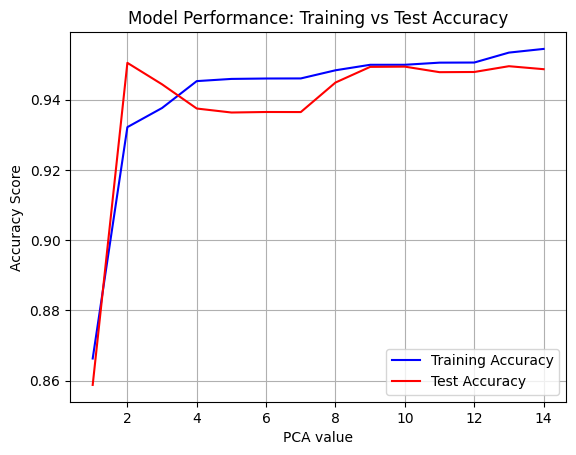

In [83]:
training_score=[]
test_score=[]
for n in range(1,15):
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_updated_bike)
    X_train_up_bike, X_test_up_bike, y_train_up_bike, y_test_up_bike = train_test_split(X_pca, Y_updated_bike, test_size=0.2, random_state=0)
    X_train_up_bike=scaler.fit_transform(X_train_up_bike)
    X_test_up_bike=scaler.transform(X_test_up_bike)
    
    #training model
    model=model_dic["Ridge"]
    model.fit(X_train_up_bike,y_train_up_bike)
    yhat_train=model.predict(X_train_up_bike)
    score_train=r2_score(y_train_up_bike,yhat_train)
    yhat=model.predict(X_test_up_bike)
    score=r2_score(y_test_up_bike,yhat)
    training_score.append(score_train)
    test_score.append(score)

#plt.figure(figsize=(20, 16))
plt.plot(range(1,15), training_score, 
         label='Training Accuracy', color='blue')

# 2. Plot the second line (it adds to the same diagram)
plt.plot(range(1,15), test_score, 
        label='Test Accuracy', color='red')

# 3. Add details to make it readable
plt.title('Model Performance: Training vs Test Accuracy')
plt.xlabel('PCA value')
plt.ylabel('Accuracy Score')
plt.legend()  # This adds the box identifying the lines
plt.grid(True)
plt.show()


The best PCA value for this model is 9

In [93]:
pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_updated_bike)
X_train_up_bike, X_test_up_bike, y_train_up_bike, y_test_up_bike = train_test_split(X_pca, Y_updated_bike, test_size=0.2, random_state=0)
X_train_up_bike=scaler.fit_transform(X_train_up_bike)
X_test_up_bike=scaler.transform(X_test_up_bike)

#training model
model=model_dic["Ridge"]
model.fit(X_train_up_bike,y_train_up_bike)
yhat_train=model.predict(X_train_up_bike)
score_train=r2_score(y_train_up_bike,yhat_train)
yhat=model.predict(X_test_up_bike)
score=r2_score(y_test_up_bike,yhat)
print(f"Training score {score_train}")
print(f"Test score {score}")

Training score 0.949912480111343
Test score 0.949319584515488


In [113]:
## analysis of chi2 amongst categorical columns
import itertools
'''
# List of columns to compare
cols = ['Brand Name', 'Region Name', 'Suburb', 'Postcode']

# Initialize an empty DataFrame for the matrix
# We use 1.0 as the default because a column compared to itself is perfectly related (p=0)
matrix_df = pd.DataFrame(index=cols, columns=cols, dtype=float)

# Iterate through every pair of columns
for col1, col2 in itertools.combinations_with_replacement(cols, 2):
    # Create the contingency table
    contingency_table = pd.crosstab(fuel_df[col1], fuel_df[col2])
    
    # Calculate chi2
    chi2, p, dof, expected = st.chi2_contingency(contingency_table)
    
    # Fill both sides of the matrix (symmetric)
    matrix_df.loc[col1, col2] = p
    matrix_df.loc[col2, col1] = p

print("Chi-Square P-Value Matrix:")
print(matrix_df)
'''

'\n# List of columns to compare\ncols = [\'Brand Name\', \'Region Name\', \'Suburb\', \'Postcode\']\n\n# Initialize an empty DataFrame for the matrix\n# We use 1.0 as the default because a column compared to itself is perfectly related (p=0)\nmatrix_df = pd.DataFrame(index=cols, columns=cols, dtype=float)\n\n# Iterate through every pair of columns\nfor col1, col2 in itertools.combinations_with_replacement(cols, 2):\n    # Create the contingency table\n    contingency_table = pd.crosstab(fuel_df[col1], fuel_df[col2])\n    \n    # Calculate chi2\n    chi2, p, dof, expected = st.chi2_contingency(contingency_table)\n    \n    # Fill both sides of the matrix (symmetric)\n    matrix_df.loc[col1, col2] = p\n    matrix_df.loc[col2, col1] = p\n\nprint("Chi-Square P-Value Matrix:")\nprint(matrix_df)\n'

Null hypothesis p>0.05 means there is no relationship between each column
Alternate hypothesis p_value<0.05 means there is a relationsip between each column

In [97]:
fuel_df.columns

Index(['FullDate', 'Brand Name', 'Region Name', 'Suburb', 'Postcode', 'Lat',
       'Long', 'Diesel', 'Premium 98', 'Premium 95', 'Unleaded 91',
       'Premium Diesel', 'LPG', 'Low Aromatic Fuel', 'Ethanol 105 (E85)',
       'Ethanol 94 (E10)', 'Total_price', 'Year'],
      dtype='object')

In [98]:
#creating dummies variable
dummies=pd.get_dummies(fuel_df[['Brand Name', 'Region Name', 'Suburb','Postcode']],dtype=int)
merged=pd.concat([fuel_df,dummies],axis="columns")

In [99]:
merged.drop(['FullDate','Brand Name', 'Region Name', 'Suburb','Postcode'],axis="columns",inplace=True)
merged

,Lat,Long,Diesel,Premium 98,Premium 95,Unleaded 91,Premium Diesel,LPG,Low Aromatic Fuel,Ethanol 105 (E85),...,Postcode_814.0,Postcode_820.0,Postcode_821.0,Postcode_822.0,Postcode_828.0,Postcode_829.0,Postcode_830.0,Postcode_831.0,Postcode_832.0,Postcode_835.0
0,-12.453169,130.838155,125.9,0.0,0.0,125.9,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,-12.454479,130.838773,149.9,0.0,166.9,149.9,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,-12.458111,130.836149,147.7,0.0,157.7,146.7,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,-12.459371,130.837418,147.9,176.9,157.9,146.9,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,-12.376822,130.882005,149.9,0.0,166.9,149.9,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82698,-12.424795,130.839007,0.0,221.9,196.9,181.9,189.9,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
82699,-12.372140,130.883700,0.0,0.0,194.9,179.9,185.9,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
82700,-12.401029,130.916358,0.0,0.0,202.9,187.9,191.9,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
82701,-12.389526,130.851965,0.0,0.0,204.9,189.9,191.9,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,0


In [100]:
X=merged.drop(['Diesel','Premium 98', 'Premium 95', 'Unleaded 91',
       'Premium Diesel', 'LPG', 'Low Aromatic Fuel', 'Ethanol 105 (E85)',
       'Ethanol 94 (E10)'],axis="columns")
Y=merged["Diesel"]
#intial training for fuel data
intial_model_prediction(X,Y)

,model,training_accuracy_score,accuracy_score
0,Linear,0.813663,0.819846
1,Lasso,0.670987,0.674367
2,Ridge,0.813605,0.819895
3,Randomforest,0.999498,0.998712
4,Decisiontree,0.999595,0.998351
5,Ada,0.715635,0.715449


In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
X_train_up_bike=scaler.fit_transform(X_train)
X_test_up_bike=scaler.transform(X_test)

#training model

model=model_dic["Randomforest"]
model.fit(X_train,y_train)
yhat_train=model.predict(X_train)
score_train=r2_score(y_train,yhat_train)
yhat=model.predict(X_test)
score=r2_score(y_test,yhat)
print(f"Training score {score_train}")
print(f"Test score {score}")


Training score 0.999511750435712
Test score 0.9987181650668971


AttributeError: 'RandomForestRegressor' object has no attribute 'coef_'

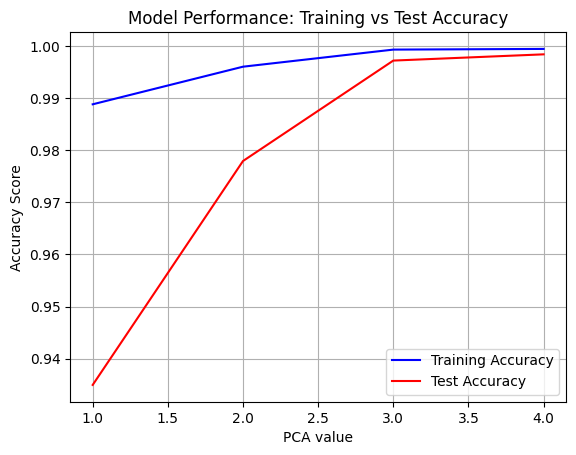

In [110]:
training_score=[]
test_score=[]
for n in range(1,5):
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size=0.2, random_state=0)
    X_train=scaler.fit_transform(X_train)
    X_test=scaler.transform(X_test)
    
    #training model
    model=model_dic["Randomforest"]
    model.fit(X_train,y_train)
    yhat_train=model.predict(X_train)
    score_train=r2_score(y_train,yhat_train)
    yhat=model.predict(X_test)
    score=r2_score(y_test,yhat)
    training_score.append(score_train)
    test_score.append(score)

#plt.figure(figsize=(20, 16))
plt.plot(range(1,5), training_score, 
         label='Training Accuracy', color='blue')

# 2. Plot the second line (it adds to the same diagram)
plt.plot(range(1,5), test_score, 
        label='Test Accuracy', color='red')

# 3. Add details to make it readable
plt.title('Model Performance: Training vs Test Accuracy')
plt.xlabel('PCA value')
plt.ylabel('Accuracy Score')
plt.legend()  # This adds the box identifying the lines
plt.grid(True)
plt.show()


In [111]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size=0.2, random_state=0)
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
    

#training model
model=model_dic["Randomforest"]
model.fit(X_train,y_train)
yhat_train=model.predict(X_train)
score_train=r2_score(y_train,yhat_train)
yhat=model.predict(X_test)
score=r2_score(y_test,yhat)
print(f"Training score {score_train}")
print(f"Test score {score}")

Training score 0.9992912292419484
Test score 0.9970935146617396
